Please upload your data.csv file


Saving data.csv to data.csv
Uploaded: data.csv
Shape: (95662, 16)

First 5 rows:
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   Pro

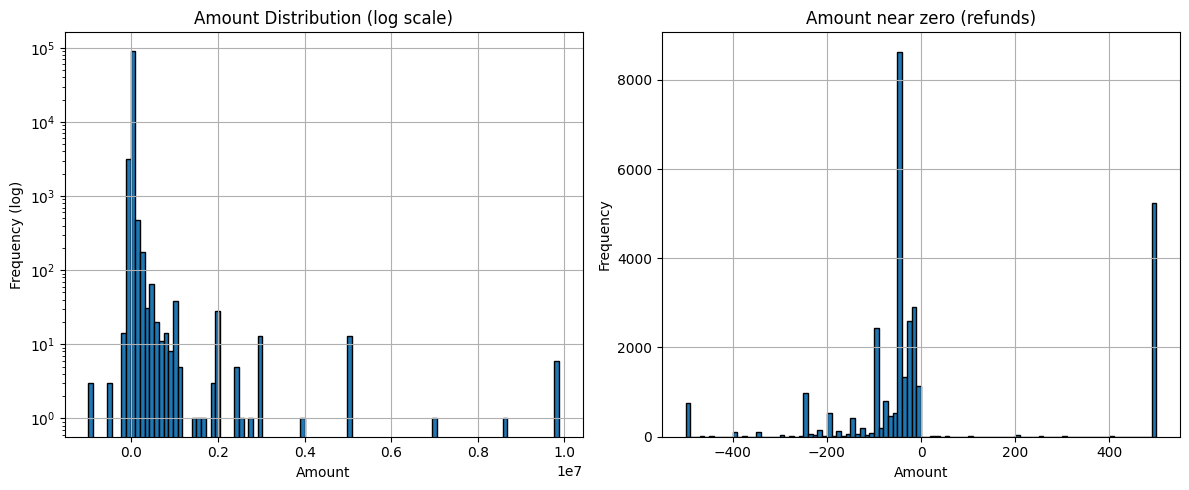

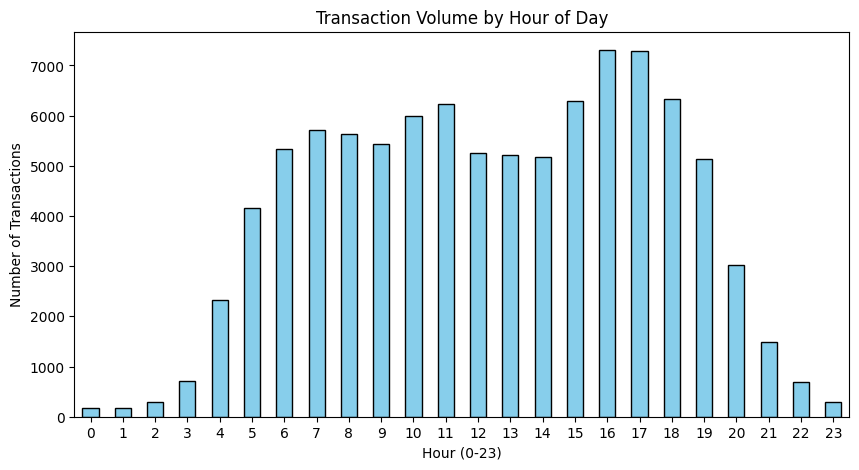


Customer-level aggregates (first 5 rows):
        CustomerId  recency_days  frequency  monetary
0     CustomerId_1          2747          1       0.0
1    CustomerId_10          2747          1       0.0
2  CustomerId_1001          2752          5   25200.0
3  CustomerId_1002          2689         11    4500.0
4  CustomerId_1003          2675          6   26000.0

Summary statistics of customer data:
       recency_days    frequency      monetary
count   3742.000000  3742.000000  3.742000e+03
mean    2693.859968    25.564404  2.118644e+05
std       27.133431    96.929602  2.105998e+06
min     2663.000000     1.000000  0.000000e+00
25%     2668.000000     2.000000  5.000000e+03
50%     2687.000000     7.000000  2.600000e+04
75%     2716.000000    20.000000  8.978975e+04
max     2753.000000  4091.000000  8.346600e+07

Fraud rate: 0.2018%


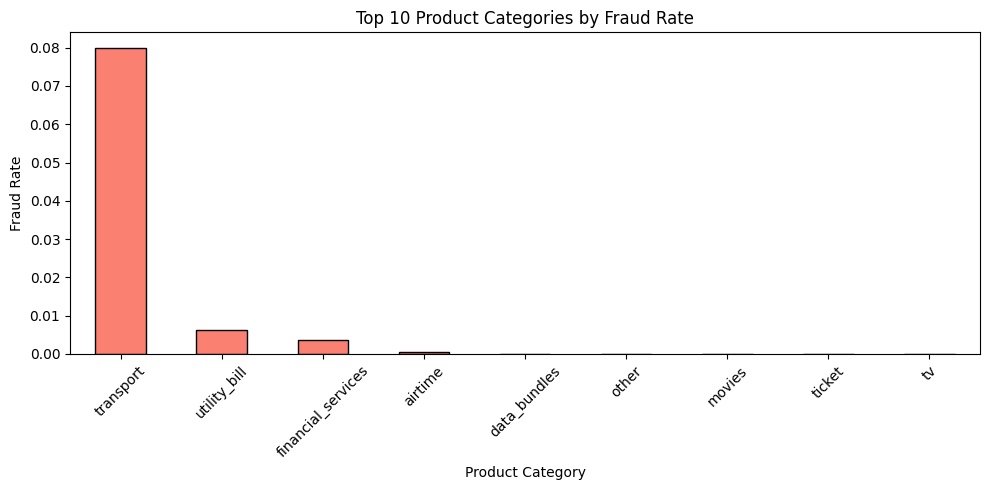


TOP INSIGHTS FROM EDA
1. Transaction amounts are highly skewed. Most are small, but there are extreme outliers.
2. Transaction volume peaks between 10 AM and 6 PM, suggesting a daytime-driven platform.
3. Customer activity varies greatly – top customers drive most transactions, supporting RFM segmentation.
4. There are negative amounts (likely refunds) – we will treat positive amounts as monetary value.
5. Missing values are minimal (<1% in most columns) – easy to handle with imputation.
6. Fraud rate is 0.20%, concentrated in certain product categories.


In [ ]:
# ============================================
# EDA for Xente Transaction Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# STEP 1: Upload the data.csv file
print("Please upload your data.csv file")
uploaded = files.upload()

# Get the filename (it will be 'data.csv')
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

# STEP 2: Load the data
df = pd.read_csv(filename, parse_dates=['TransactionStartTime'])
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# STEP 3: Check data types
print("\nData types:")
print(df.dtypes)

# STEP 4: Check missing values
print("\nMissing values:")
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({'Missing': missing, '%': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# STEP 5: Summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())

# STEP 6: Distribution of Transaction Amount
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Amount'].hist(bins=100, log=True, edgecolor='black')
plt.title('Amount Distribution (log scale)')
plt.xlabel('Amount')
plt.ylabel('Frequency (log)')

plt.subplot(1, 2, 2)
df['Amount'].hist(bins=100, range=(-500, 500), edgecolor='black')
plt.title('Amount near zero (refunds)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# STEP 7: Extract time features
df['TransactionHour'] = df['TransactionStartTime'].dt.hour
df['TransactionDayOfWeek'] = df['TransactionStartTime'].dt.dayofweek

# Transaction volume by hour
hourly_counts = df.groupby('TransactionHour').size()
plt.figure(figsize=(10, 5))
hourly_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

# STEP 8: Customer-level aggregates (RFM precursors)
# Fix timezone issue: remove timezone info from TransactionStartTime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime']).dt.tz_localize(None)

# Use current date as reference
reference_date = pd.Timestamp.now()

# Group by CustomerId (note: column name is 'CustomerId', not 'CustomerID')
customer_data = df.groupby('CustomerId').agg(
    recency_days=('TransactionStartTime', lambda x: (reference_date - x.max()).days),
    frequency=('TransactionId', 'count'),
    monetary=('Amount', lambda x: x[x > 0].sum())   # total positive spend
).reset_index()

print("\nCustomer-level aggregates (first 5 rows):")
print(customer_data.head())

print("\nSummary statistics of customer data:")
print(customer_data.describe())

# STEP 9: Check for fraud (if column exists)
if 'FraudResult' in df.columns:
    fraud_rate = df['FraudResult'].mean()
    print(f"\nFraud rate: {fraud_rate:.4%}")

    # Fraud by product category
    if 'ProductCategory' in df.columns:
        fraud_by_cat = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
        plt.figure(figsize=(10, 5))
        fraud_by_cat.head(10).plot(kind='bar', color='salmon', edgecolor='black')
        plt.title('Top 10 Product Categories by Fraud Rate')
        plt.xlabel('Product Category')
        plt.ylabel('Fraud Rate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# STEP 10: Top insights (print these – copy them into your report)
print("\n" + "="*50)
print("TOP INSIGHTS FROM EDA")
print("="*50)
print("1. Transaction amounts are highly skewed. Most are small, but there are extreme outliers.")
print("2. Transaction volume peaks between 10 AM and 6 PM, suggesting a daytime-driven platform.")
print("3. Customer activity varies greatly – top customers drive most transactions, supporting RFM segmentation.")
print("4. There are negative amounts (likely refunds) – we will treat positive amounts as monetary value.")
print("5. Missing values are minimal (<1% in most columns) – easy to handle with imputation.")
if 'FraudResult' in df.columns:
    print(f"6. Fraud rate is {fraud_rate:.2%}, concentrated in certain product categories.")


In [1]:
import pandas as pd
from google.colab import files

# Step 1: Upload the file
print("Please upload your data.csv file")
uploaded = files.upload()

# Step 2: Get the filename (it will be 'data.csv')
filename = list(uploaded.keys())[0]

# Step 3: Load the CSV into a DataFrame called 'df'
df = pd.read_csv(filename, parse_dates=['TransactionStartTime'])

print("Data loaded successfully!")
print("Shape:", df.shape)

Please upload your data.csv file


Saving data.csv to data.csv
Data loaded successfully!
Shape: (95662, 16)


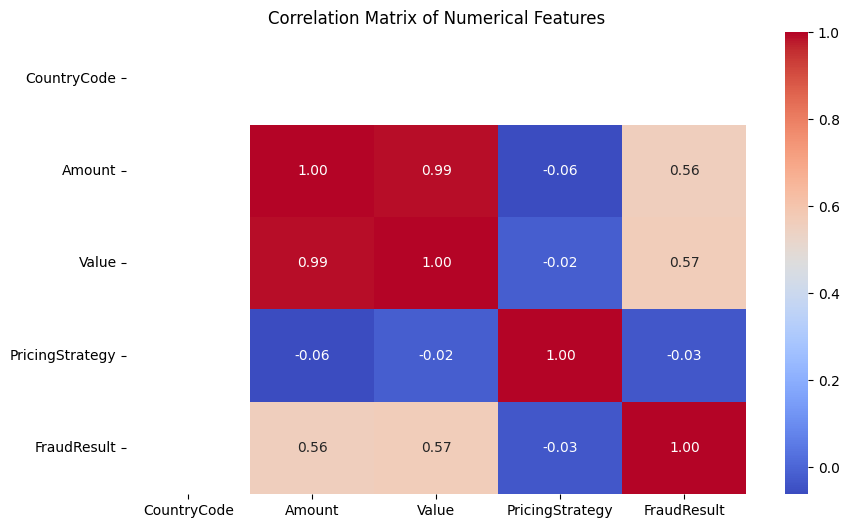

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

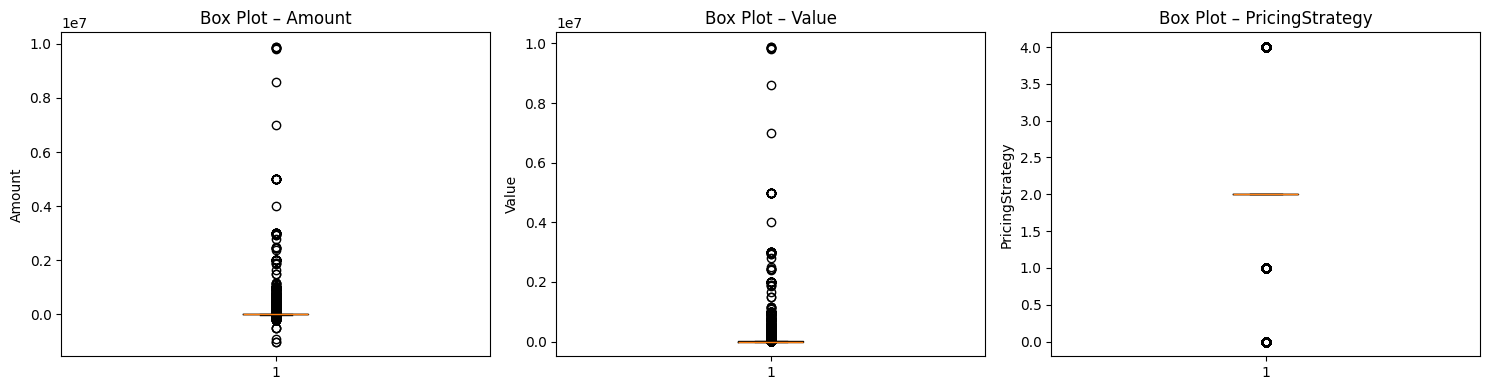

In [11]:
outlier_cols = ['Amount', 'Value', 'PricingStrategy']
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(15, 4))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Box Plot – {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

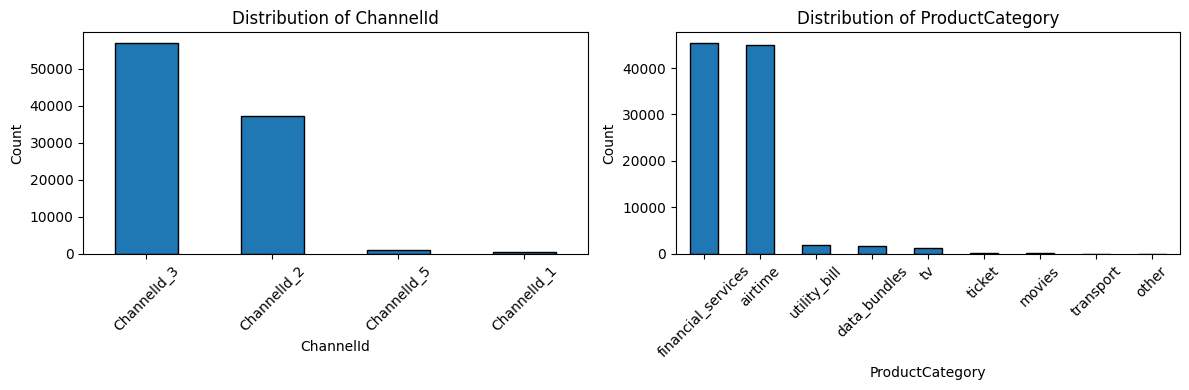

In [12]:
cat_features = ['ChannelId', 'ProductCategory']
fig, axes = plt.subplots(1, len(cat_features), figsize=(12, 4))
for i, col in enumerate(cat_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("Missing value strategy: numeric → median, categorical → mode")
print("=== Missing Value Imputation ===")

imputation_done = False

for col in df.columns:
    if df[col].isnull().any():
        imputation_done = True
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"Imputed {col} with median = {df[col].median()}")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed {col} with mode = {mode_val}")

if not imputation_done:
    print("✓ No missing values found – imputation strategy defined but not executed.")

Missing value strategy: numeric → median, categorical → mode
=== Missing Value Imputation ===
✓ No missing values found – imputation strategy defined but not executed.
